In [1]:
!pip install duckdb

In [26]:
import pandas as pd
import os
import glob
import numpy as np
import requests
from pathlib import Path
import time
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

## Functions

In [19]:
def baixar_arquivo_parquet(url: str, pasta_destino: str, nome_arquivo: str, mes: str):
    try:
        output_folder = Path(pasta_destino)

        output_folder.mkdir(parents=True, exist_ok=True)

        nome_arquivo = nome_arquivo+".parquet"

        file_path = output_folder / nome_arquivo

        print(f"Iniciando o download de: {mes}")

        with requests.get(url, stream=True) as response:
            response.raise_for_status()

            with open(file_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            print(f"\nDownload concluído com sucesso!")
            return file_path
    except requests.exceptions.RequestException as e:
        print(f"\nERRO: Falha ao baixar o arquivo para o mês de {mes}.")
        print(f"Detalhes do erro: {e}")
        return None

In [20]:
def load_files(archives_dir_path):
    df = pd.DataFrame()
    for file_path in glob.glob(os.path.join(archives_dir_path, "*.parquet")):
        if df.empty:
            df = pd.read_parquet(file_path)

            df_col = df.columns.values
            df_col = [item.lower() for item in df_col]
            df_col = [item.strip() for item in df_col]
            df_col = [item.replace(" ", "_") for item in df_col]


            rename_dict = dict(zip(df.columns.values, df_col))
            df.rename(columns=rename_dict, inplace=True)
        else:
            df_aux = pd.read_parquet(file_path)

            df_col = df_aux.columns.values
            df_col = [item.lower() for item in df_col]
            df_col = [item.strip() for item in df_col]
            df_col = [item.replace(" ", "_") for item in df_col]

            rename_dict = dict(zip(df_aux.columns.values, df_col))
            df_aux.rename(columns=rename_dict, inplace=True)

            df = pd.concat([df, df_aux])

    return df


In [21]:
def benchmark_parquet_pandas(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = pd.read_parquet(archive_path, index_col=0)
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [22]:
def benchmark_csv_pandas(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = pd.read_csv(archive_path, index_col=0)
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [23]:
def benchmark_csv_duckdb(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = duckdb.query(f"SELECT * FROM read_csv_auto('{archive_path}');").df()
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [24]:
def benchmark_parquet_duckdb(csv_path: str, amount: int):
  archive_path = Path(csv_path)
  times = []
  gc.collect()

  for i in range(amount):
    print(f"Começando a iteração: {i}\n")
    start = time.perf_counter()
    df = duckdb.query(f"SELECT * FROM '{archive_path}';").df()
    end = time.perf_counter()
    times.append(end - start)
    del df
    gc.collect()
  return times

In [25]:
def print_metrics(array):
  print(f"Média: {round(np.mean(array), 2)}")
  print(f"Desvio Padrão: {round(np.std(array), 2)}")
  print("\n")

## Code

In [23]:
archives_dir_path = Path("./parquet_files/")

### Download Automatizado
- Análise e padronização dos schemas

In [24]:
for i in range(1, 13):
    if i < 10:
        url_download = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-0{i}.parquet"
    else:
        url_download = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-{i}.parquet"

    url2 = baixar_arquivo_parquet(url_download, archives_dir_path, f"saida_{i}", f"{i}")

Iniciando o download de: 1

Download concluído com sucesso!
Iniciando o download de: 2

Download concluído com sucesso!
Iniciando o download de: 3

Download concluído com sucesso!
Iniciando o download de: 4

Download concluído com sucesso!
Iniciando o download de: 5

Download concluído com sucesso!
Iniciando o download de: 6

Download concluído com sucesso!
Iniciando o download de: 7

Download concluído com sucesso!
Iniciando o download de: 8

Download concluído com sucesso!
Iniciando o download de: 9

Download concluído com sucesso!
Iniciando o download de: 10

Download concluído com sucesso!
Iniciando o download de: 11

Download concluído com sucesso!
Iniciando o download de: 12

Download concluído com sucesso!


### Limpeza dos Dados

In [25]:
df = load_files(archives_dir_path)

KeyboardInterrupt: 

In [ ]:
df.head()

In [ ]:
# Tempo negativo e zero
drop_indexes = df[df["tpep_pickup_datetime"] >= df["tpep_dropoff_datetime"]].index
df.drop(drop_indexes, inplace=True)

In [ ]:
# Monetário negativo
monetary_cols = ['fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee']
for col in monetary_cols:
  df.drop(df[df[col] < 0].index, inplace=True)

In [ ]:
# Sem passageiros
df.drop(df[df["passenger_count"] == 0.0].index, inplace=True)

In [ ]:
# Dentro do periodo esperado
lower_bound = pd.to_datetime("01/01/2023")
upper_bound = pd.to_datetime("01/01/2024")

df.drop(df[(df["tpep_pickup_datetime"] <= lower_bound) | (df["tpep_pickup_datetime"] >= upper_bound)].index, inplace=True)
df.drop(df[(df["tpep_dropoff_datetime"] <= lower_bound) | (df["tpep_dropoff_datetime"] >= upper_bound)].index, inplace=True)

In [ ]:
len(df)

### Armazenamento

In [ ]:
df.to_csv("./taxi_csv.csv")

In [ ]:
df.to_parquet('./taxi_snappy.parquet', compression='snappy')

In [ ]:
df.to_parquet('./taxi_zstd.parquet', compression='zstd')

### Os tamanhos são:


In [32]:
tamanho_csv = Path('./taxi_csv.csv').stat().st_size
tamanho_snappy = Path('./taxi_snappy.parquet').stat().st_size
tamanho_zstd = Path('./taxi_zstd.parquet').stat().st_size

print(f"Tamanho CSV: {tamanho_csv / 1e6:.2f} MB")
print(f"Tamanho Parquet Snappy: {tamanho_snappy / 1e6:.2f} MB")
print(f"Tamanho Parquet ZSTD: {tamanho_zstd / 1e6:.2f} MB")

Tamanho CSV: 3195.38 MB
Tamanho Parquet Snappy: 717.86 MB
Tamanho Parquet ZSTD: 523.04 MB


In [26]:
df

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
7,2,2023-10-01 00:11:29,2023-10-01 00:32:55,2.0,14.93,1.0,N,208,239,1,37.30,1.0,0.5,14.77,6.94,1.0,65.76,2.5,1.75
9,1,2023-10-01 00:39:47,2023-10-01 00:48:48,1.0,1.30,1.0,N,125,231,1,10.00,3.5,0.5,2.00,0.00,1.0,17.00,2.5,0.00
11,2,2023-10-01 00:11:49,2023-10-01 00:33:31,1.0,2.52,1.0,N,232,158,1,19.10,1.0,0.5,4.82,0.00,1.0,28.92,2.5,0.00
12,2,2023-10-01 00:51:42,2023-10-01 01:02:51,2.0,4.04,1.0,N,161,42,1,17.70,1.0,0.5,4.54,0.00,1.0,27.24,2.5,0.00
13,2,2023-10-01 00:16:19,2023-10-01 00:27:27,1.0,1.70,1.0,N,148,170,1,11.40,1.0,0.5,3.28,0.00,1.0,19.68,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2846715,2,2023-09-30 23:08:00,2023-09-30 23:30:59,NaN,5.13,NaN,None,89,225,0,26.57,0.0,0.5,0.00,0.00,1.0,28.07,NaN,NaN
2846716,2,2023-09-30 23:28:48,2023-09-30 23:35:59,NaN,1.36,NaN,None,229,140,0,14.48,0.0,0.5,3.70,0.00,1.0,22.18,NaN,NaN
2846718,1,2023-09-30 23:42:18,2023-09-30 23:47:45,NaN,0.00,NaN,None,236,75,0,11.33,0.0,0.5,0.00,0.00,1.0,15.33,NaN,NaN
2846719,1,2023-09-30 23:03:35,2023-09-30 23:14:50,NaN,1.80,NaN,None,211,90,0,12.10,1.0,0.5,2.57,0.00,1.0,19.67,NaN,NaN


### Perguntas:
  - Houve mudanças de schema entre os meses?
    - Houve mudanças, na questão da padronização dos nomes das colunas
  - Qual estratégia para dados ausentes/inconsistentes?
    - Como pedido foram removidas as colunas que não se encaixavam no contexto correto
  - Como garantir reprodutibilidade do processo? Ou seja, outros analistas chegariam no
mesmo resultado que você?
    - Para garantir a reprodutibilidade foram as ações foram feitas por chamadas de função, garantindo que seja necessário apenas alterar na função, e não precisar desbrava o código ao longo das células


# Tarefa 2: Benchmark de Performance

### Tamanho dos Arquivos

In [31]:
tamanho_csv = Path('./taxi_csv.csv').stat().st_size
tamanho_snappy = Path('./taxi_snappy.parquet').stat().st_size
tamanho_zstd = Path('./taxi_zstd.parquet').stat().st_size

print(f"Tamanho CSV: {tamanho_csv / 1e6:.2f} MB")
print(f"Tamanho Parquet Snappy: {tamanho_snappy / 1e6:.2f} MB")
print(f"Tamanho Parquet ZSTD: {tamanho_zstd / 1e6:.2f} MB")

Tamanho CSV: 3195.38 MB
Tamanho Parquet Snappy: 717.86 MB
Tamanho Parquet ZSTD: 523.04 MB


### Taxa de Compressão

In [33]:
# Taxa de compressão relativa (quanto % do original ele ocupa)
taxa_snappy = (tamanho_snappy / tamanho_csv) * 100
taxa_zstd = (tamanho_zstd / tamanho_csv) * 100

# Redução percentual de tamanho (espaço economizado)
reducao_snappy = (1 - (tamanho_snappy / tamanho_csv)) * 100
reducao_zstd = (1 - (tamanho_zstd / tamanho_csv)) * 100

print("--- Análise de Compressão Relativa ao CSV ---")
print(f"Tamanho CSV (Base): {tamanho_csv / 1e6:.2f} MB")
print("-" * 40)
print(f"Tamanho Parquet Snappy: {tamanho_snappy / 1e6:.2f} MB")
print(f"  -> Ocupa {taxa_snappy:.2f}% do tamanho do CSV.")
print(f"  -> Redução de {reducao_snappy:.2f}% em relação ao CSV.")
print("-" * 40)
print(f"Tamanho Parquet ZSTD: {tamanho_zstd / 1e6:.2f} MB")
print(f"  -> Ocupa {taxa_zstd:.2f}% do tamanho do CSV.")
print(f"  -> Redução de {reducao_zstd:.2f}% em relação ao CSV.")
print("-" * 40)


--- Análise de Compressão Relativa ao CSV ---
Tamanho CSV (Base): 3195.38 MB
----------------------------------------
Tamanho Parquet Snappy: 717.86 MB
  -> Ocupa 22.47% do tamanho do CSV.
  -> Redução de 77.53% em relação ao CSV.
----------------------------------------
Tamanho Parquet ZSTD: 523.04 MB
  -> Ocupa 16.37% do tamanho do CSV.
  -> Redução de 83.63% em relação ao CSV.
----------------------------------------


### Visualização

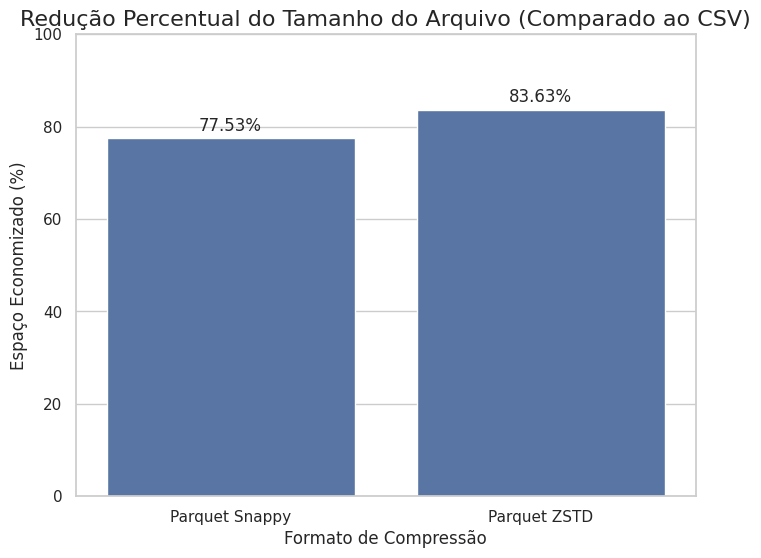

In [35]:
dados_grafico = {
    'Formato': ['Parquet Snappy', 'Parquet ZSTD'],
    'Redução de Tamanho (%)': [reducao_snappy, reducao_zstd]
}
df_grafico = pd.DataFrame(dados_grafico)

# Criando o gráfico
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
barplot = sns.barplot(x='Formato', y='Redução de Tamanho (%)', data=df_grafico)

# Adicionando os valores no topo das barras
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Redução Percentual do Tamanho do Arquivo (Comparado ao CSV)', fontsize=16)
plt.ylabel('Espaço Economizado (%)', fontsize=12)
plt.xlabel('Formato de Compressão', fontsize=12)
plt.ylim(0, 100) # O eixo y vai de 0 a 100%
plt.show()

## Benchmark de carregamento:

In [53]:
csv_times = benchmark_csv_pandas("./taxi_csv.csv", 5)

Começando a iteração: 0



/tmp/ipython-input-921010755.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 1



/tmp/ipython-input-921010755.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 2



/tmp/ipython-input-921010755.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 3



/tmp/ipython-input-921010755.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


Começando a iteração: 4



/tmp/ipython-input-921010755.py:9: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archive_path, index_col=0)


In [58]:
csv_times_duckdb = benchmark_csv_duckdb("./taxi_csv.csv", 5)

Começando a iteração: 0



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 1



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 2



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 3



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Começando a iteração: 4



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
parquet_times_duckdb = benchmark_parquet_duckdb("./taxi_zstd.parquet", 5)

Começando a iteração: 0



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
parquet_times_pandas = benchmark_parquet_pandas("./taxi_zstd.parquet", 5)

In [69]:
print_metrics(csv_times)
print_metrics(csv_times_duckdb)


Média: 34.47
Desvio Padrão: 0.93


Média: 8.71
Desvio Padrão: 0.42




np.float64(8.705174698800146)

In [54]:
csv_times

[36.29889793299981,
 34.3843945550002,
 33.770540918999814,
 33.977668834999804,
 33.935825770000065]